In [ ]:
%load_ext rpy2.ipython

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%R
install.packages('ComplexUpset', repos='http://cran.us.r-project.org')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘patchwork’, ‘colorspace’

trying URL 'http://cran.us.r-project.org/src/contrib/patchwork_1.3.2.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/colorspace_2.1-2.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/ComplexUpset_1.3.3.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpoEssap/downloaded_packages’


In [ ]:
%%R
library(ggplot2)
library(ComplexUpset)

In [ ]:
import pandas as pd

In [ ]:
file_d={}
# in github directory: '../results/regulator_pathways/'
base_path = '/content/drive/MyDrive/mrsa/regulator_pathways/'
file_d['AREG'] = pd.ExcelFile(base_path + 'AREG_REGULATOR_PATHWAYS.xlsx')
file_d['ATM'] = pd.ExcelFile(base_path + 'ATM_REGULATOR_PATHWAYS.xlsx')
file_d['CUL4B'] = pd.ExcelFile(base_path + 'CUL4B_REGULATOR_PATHWAYS.xlsx')
file_d['MYC'] = pd.ExcelFile(base_path + 'MYC_REGULATOR_PATHWAYS.xlsx')
file_d['Pkg'] = pd.ExcelFile(base_path + 'Pkg_REGULATOR_PATHWAYS.xlsx')
file_d['Rac'] = pd.ExcelFile(base_path + 'Rac_REGULATOR_PATHWAYS.xlsx')
file_d['ROCK'] = pd.ExcelFile(base_path + 'ROCK_REGULATOR_PATHWAYS.xlsx')

d={k:set() for k in file_d.keys()}
for k in d.keys():
    #print(k)
    for sheet in file_d[k].sheet_names:
        df = pd.read_excel(file_d[k], sheet_name=sheet, index_col=0)
        #print(len(set(df['GENE'])))
        #print(len(d[k].union(set(df['GENE']))))
        d[k] = d[k].union(set(df['GENE']))

In [ ]:
unique_genes_across_all_regulators = list(set([gene for regulator_genes in d.values() for gene in regulator_genes]))
master = pd.DataFrame(columns=['Dataset']+list(d.keys()), index=[l for k in unique_genes_across_all_regulators for l in [k]*3]) # Adjusted to 3 datasets
master['Dataset']=['6HR_MRSA', '24HR_MRSA', 'PROT']*len(unique_genes_across_all_regulators)

In [ ]:
# %%R -w 800 -h 500

# upset(
#     master,
#     regs,
#     name='Regulator',
#     # Removed 'Dataset' annotation as only 'PROT' data is being used.
#     # The 'Dataset' column is constant and not informative for an annotation.
#     # annotations = list(
#     #     'Dataset'=(
#     #         ggplot(mapping=aes(fill=Dataset))
#     #         + geom_bar(stat='count', position='fill')
#     #         + scale_y_continuous(labels=scales::percent_format())
#     #     )
#     # ),
#     width_ratio=0.1
# )
# # ggsave('../results/results_012122/021622/upset_v2.pdf', bg="transparent")

In [ ]:
data_d = {'6HR_MRSA':{k:set() for k in file_d.keys()}, '24HR_MRSA':{k:set() for k in file_d.keys()}, \
          'PROT':{k:set() for k in file_d.keys()}} # 'PHOS' removed
for k in file_d.keys():
    for sheet in file_d[k].sheet_names:
        df = pd.read_excel(file_d[k], sheet_name=sheet, index_col=0)
        # Populate '6HR_MRSA' data
        if 'GENE' in df.columns and 'DEG_6HR_MRSA_ADJPVAL' in df.columns and 'DEG_6HR_MRSA_LOG2FC' in df.columns:
            data_d['6HR_MRSA'][k].update(df.loc[df['DEG_6HR_MRSA_ADJPVAL']<=0.05].loc[abs(df['DEG_6HR_MRSA_LOG2FC'])>=0.585]['GENE'].tolist())
        else:
            print(f"Warning: 'GENE', 'DEG_6HR_MRSA_ADJPVAL' or 'DEG_6HR_MRSA_LOG2FC' column missing in sheet {sheet} for regulator {k}")

        # Populate '24HR_MRSA' data
        if 'GENE' in df.columns and 'DEG_24HR_MRSA_ADJPVAL' in df.columns and 'DEG_24HR_MRSA_LOG2FC' in df.columns:
            data_d['24HR_MRSA'][k].update(df.loc[df['DEG_24HR_MRSA_ADJPVAL']<=0.05].loc[abs(df['DEG_24HR_MRSA_LOG2FC'])>=0.585]['GENE'].tolist())
        else:
            print(f"Warning: 'GENE', 'DEG_24HR_MRSA_ADJPVAL' or 'DEG_24HR_MRSA_LOG2FC' column missing in sheet {sheet} for regulator {k}")

        # Populate 'PROT' data
        if 'GENE' in df.columns and 'PROT_ADJPVAL' in df.columns:
            data_d['PROT'][k].update(df.loc[df['PROT_ADJPVAL']<=0.05]['GENE'].tolist())
        else:
            print(f"Warning: 'GENE' or 'PROT_ADJPVAL' column missing in sheet {sheet} for regulator {k}")

In [ ]:
AREG=[]
ATM=[]
CUL4B=[]
MYC=[]
Pkg=[]
Rac=[]
ROCK=[]

for i,j in zip(master.index, master['Dataset']):
    for reg in ['AREG','ATM','CUL4B','MYC','Pkg','Rac','ROCK']:
        if reg=='AREG':
            AREG.append(i in data_d[j][reg])
        elif reg=='ATM':
            ATM.append(i in data_d[j][reg])
        elif reg=='CUL4B':
            CUL4B.append(i in data_d[j][reg])
        elif reg=='MYC':
            MYC.append(i in data_d[j][reg])
        elif reg=='Pkg':
            Pkg.append(i in data_d[j][reg])
        elif reg=='Rac':
            Rac.append(i in data_d[j][reg])
        elif reg=='ROCK':
            ROCK.append(i in data_d[j][reg])
master['AREG']=AREG
master['ATM']=ATM
master['CUL4B']=CUL4B
master['MYC']=MYC
master['Pkg']=Pkg
master['Rac']=Rac
master['ROCK']=ROCK

In [ ]:
regs=['AREG','ATM','CUL4B','MYC','Pkg','Rac','ROCK']
master=master.reset_index()
drop_indx = list(master.loc[master['ATM']==False].loc[master['AREG']==False].loc[master['CUL4B']==False].loc[master['MYC']==False].loc[master['Pkg']==False].loc[master['Rac']==False].loc[master['ROCK']==False].index)
master.drop(master.index[drop_indx], inplace=True)

In [ ]:
master.head()

,index,Dataset,AREG,ATM,CUL4B,MYC,Pkg,Rac,ROCK
0,BAG1,6HR_MRSA,False,True,True,True,True,True,True
1,BAG1,24HR_MRSA,False,True,True,True,True,True,True
2,BAG1,PROT,False,True,True,True,True,True,True
5,GIGYF2,PROT,False,True,True,True,True,True,True
8,AKT2,PROT,False,True,False,False,False,False,False


In [ ]:
master.loc[master['CUL4B']==True]

,index,Dataset,AREG,ATM,CUL4B,MYC,Pkg,Rac,ROCK
0,BAG1,6HR_MRSA,False,True,True,True,True,True,True
1,BAG1,24HR_MRSA,False,True,True,True,True,True,True
2,BAG1,PROT,False,True,True,True,True,True,True
5,GIGYF2,PROT,False,True,True,True,True,True,True
9,MX1,6HR_MRSA,True,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...
1801,CD151,24HR_MRSA,False,True,True,True,True,True,True
1802,CD151,PROT,False,True,True,True,True,True,True
1812,IFIT1,6HR_MRSA,True,True,True,True,True,True,True
1813,IFIT1,24HR_MRSA,True,True,True,True,True,True,True


In [ ]:
temp = master.loc[master['AREG']==False].loc\
[master['ATM']==False].loc[master['CUL4B']==False].loc\
[master['MYC']==False].loc[master['Pkg']==False].loc\
[master['Rac']==False].loc[master['ROCK']==True]
#[print(i, j) for i, j in zip(temp['index'], temp['Dataset'])]

In [ ]:
%R -i master -i regs

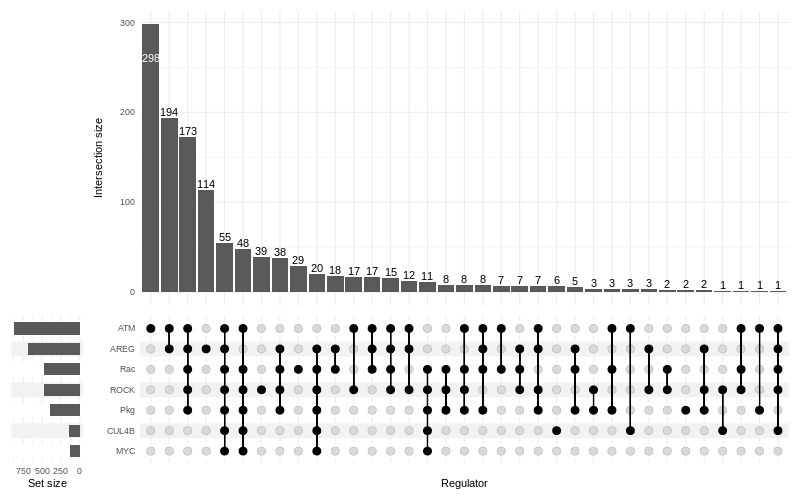

In [ ]:
%%R -w 800 -h 500

# Ensure 'regs' is defined as an R character vector within the R environment
regs <- c("AREG", "ATM", "CUL4B", "MYC", "Pkg", "Rac", "ROCK")

upset(
    master,
    regs, # 'regs' is passed as the second positional argument
    name='Regulator',
    # Removed all custom intersections and annotations to revert to a basic working version
    width_ratio=0.1
)
# ggsave('../results/results_012122/021622/upset_v2.pdf', bg="transparent")

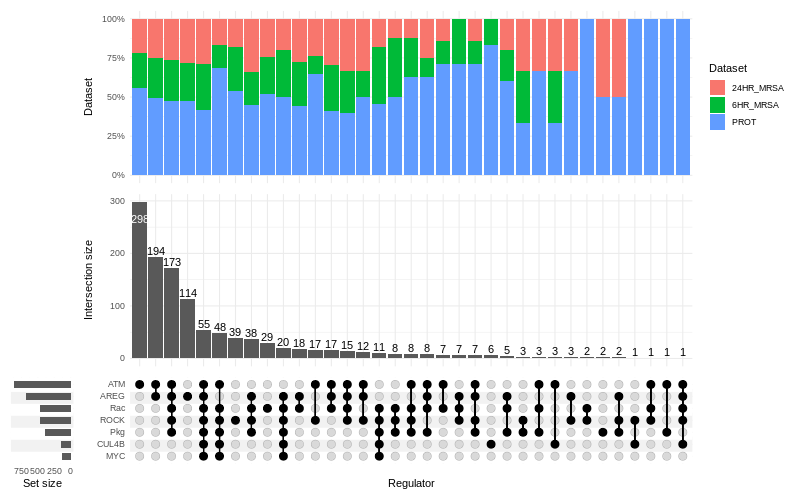

In [ ]:
%%R -w 800 -h 500

p <- upset(
    master,
    regs,
    name='Regulator',
    annotations = list(
        'Dataset'=(
            ggplot(mapping=aes(fill=Dataset))
            + geom_bar(stat='count', position='fill')
            + scale_y_continuous(labels=scales::percent_format())
        )
    ),
    width_ratio=0.1
)
print(p)
# ggsave('upset_plot.svg', bg="transparent")

In [ ]:
%%R

# --- USER INPUT REQUIRED --- #
# Specify the desired path and filename for the SVG file in Google Drive.
output_svg_path <- "/content/drive/MyDrive/mrsa/1D_upsetplot.svg"
# --- END USER INPUT --- #

# Save the plot as an SVG file
ggsave(filename = output_svg_path, plot = p, device = "svg",width = 11, height = 8)

In [ ]:
# import shutil
# import os

# source_path = 'upset_plot.svg'
# destination_folder = '/content/drive/MyDrive/mrsa/prot/'

# # Create the destination folder if it doesn't exist
# os.makedirs(destination_folder, exist_ok=True)

# # Move the file
# shutil.move(source_path, destination_folder)

# print(f"'{source_path}' moved to '{destination_folder}'")